# Notebook 10 – Stichproben und Gesetz der großen Zahlen

## 1. Einführung: Population und Stichprobe
### 1.1 Definitionen
- **Population**: Gesamtheit aller möglichen Beobachtungen $X_1, X_2, \dots, X_N$
- **Stichprobe**: Endliche Auswahl der Population $x_1, x_2, \dots, x_n$, wobei $n \ll N$

### 1.2 Relevanz für Data Science
- Trainings- und Testdaten
- Schätzung von Mittelwerten, Varianzen, Kovarianzen

### 1.3 Intuition
- Vollständige Population meist nicht verfügbar
- Stichprobengröße beeinflusst die Genauigkeit der Schätzungen

---

## 2. Deskriptive Statistik von Stichproben
### 2.1 Stichprobenmittelwert
$$
\bar X_n = \frac{1}{n} \sum_{i=1}^{n} X_i
$$
- Python: `np.mean(stichprobe)`

### 2.2 Stichprobenvarianz
$$
S^2 = \frac{1}{n-1} \sum_{i=1}^{n} (X_i - \bar X_n)^2
$$

### 2.3 Standardabweichung
$$
S = \sqrt{S^2}
$$
- Visualisierung: Histogramme der Stichprobenwerte

---

## 3. Gesetz der großen Zahlen (LLN)
### 3.1 Intuition
- Mittelwert konvergiert gegen Populationsmittelwert $\mu$ für $n \to \infty$

### 3.2 Mathematische Form
$$
\bar X_n \xrightarrow{n \to \infty} \mu
$$

### 3.3 Praktische Demonstration
- Simulation: Würfelwürfe oder Zufallszahlen
- Plot: $\bar X_n$ vs. Stichprobengröße $n$

### 3.4 Beobachtungen
- Kleine Stichproben → große Schwankungen
- Große Stichproben → Mittelwert stabilisiert sich

### 3.5 Relevanz in ML
- Feature-Normalisierung
- Stabile Schätzungen für Regularisierung

---

## 4. Zentraler Grenzwertsatz (CLT)
### 4.1 Intuition
- Verteilung der Mittelwerte wird normal, unabhängig von Populationsverteilung

### 4.2 Mathematische Form
$$
Z_n = \frac{\bar X_n - \mu}{\sigma / \sqrt{n}} \xrightarrow{d} \mathcal{N}(0,1), \quad n \to \infty
$$

### 4.3 Simulation
- Histogramm der Mittelwerte aus vielen Stichproben
- Vergleich Uniform vs. Normal

### 4.4 Standardabweichung der Mittelwerte
$$
\sigma_{\bar X} = \frac{\sigma}{\sqrt{n}}
$$

### 4.5 Anwendungen in Data Science
- Mini-Batch Gradient Descent
- Konfidenzintervalle für Schätzer

---

## 5. Stichprobenfehler & Konfidenzintervalle
### 5.1 Stichprobenfehler
$$
\text{Fehler} = \bar X_n - \mu
$$

### 5.2 Konfidenzintervall
$$
\text{CI}_{95\%} = \bar X_n \pm 1.96 \frac{S}{\sqrt{n}}
$$

### 5.3 Python-Simulation
- Mittelwerte mit Konfidenzintervallen für verschiedene Stichprobengrößen visualisieren

### 5.4 Relevanz in ML
- Unsicherheit von Feature-Schätzungen
- Evaluation von Modellmetriken

---

## 6. Stichprobengröße & Schätzfehler
### 6.1 Zusammenhang zwischen $n$ und Varianz
$$
\mathrm{Var}(\bar X_n) = \frac{\sigma^2}{n}
$$

### 6.2 Visualisierung
- Konvergenz des Mittelwerts bei steigender Stichprobengröße

### 6.3 Beispiele in Data Science
- Training/Validation Split: Einfluss von $n$ auf Genauigkeit
- Bootstrapping / Resampling Methoden

---

## 7. Simulationen und praktische Übungen
### 7.1 Würfelwurf-Simulation
- Mittelwert vs. Anzahl Würfe
- Histogramm der Mittelwerte für viele Stichproben

### 7.2 Vergleich verschiedener Populationen
- Normal, Uniform, Bernoulli
- Beobachtung: CLT greift auch bei nicht-normalen Populationen

### 7.3 Einfluss von Ausreißern
- Vergleich Mittelwert vs. Median

### 7.4 Übungen
- Berechne Konfidenzintervall für Mittelwerte
- Beobachte Schwankungen bei kleinen $n$
- Diskutiere notwendige Stichprobengröße für stabile Schätzungen

---

## 8. Zusammenfassung & Takeaways
- Stichproben bilden die Grundlage für Statistik in ML
- LLN erklärt Konvergenz des Mittelwerts
- CLT erlaubt Normalapproximation für Mittelwerte
- Stichprobengröße beeinflusst Schätzunsicherheit
- Python-Simulationen festigen Intuition

---

## 9. Verbindung zu Machine Learning
- Feature-Standardisierung
- Bootstrapping und Resampling
- Mini-Batch Training & SGD
- Konfidenzintervalle für Modelle
- Parameter-Schätzung bei probabilistischen Modellen (Basis für MLE)


## 1. Population und Stichprobe – Detailliert

### 1.1 Definitionen (mathematisch)
- **Population**: Sei $X$ eine Zufallsvariable über einer Grundgesamtheit. Dann ist die Population die Gesamtheit aller möglichen Realisierungen $X_1, X_2, \dots, X_N$.  

  Populationsparameter:
  - Erwartungswert (Mean):
  $$
  \mu = \mathbb{E}[X] = \frac{1}{N} \sum_{i=1}^{N} X_i
  $$
  - Varianz:
  $$
  \sigma^2 = \mathbb{E}[(X - \mu)^2] = \frac{1}{N} \sum_{i=1}^{N} (X_i - \mu)^2
  $$

- **Stichprobe**: Eine Teilmenge von $n$ Beobachtungen aus der Population ($n \ll N$):
$$
x_1, x_2, \dots, x_n
$$
Schätzer für Populationsparameter:
- Stichprobenmittelwert:
$$
\bar X_n = \frac{1}{n} \sum_{i=1}^{n} x_i
$$
- Stichprobenvarianz (unbiased):
$$
S^2 = \frac{1}{n-1} \sum_{i=1}^{n} (x_i - \bar X_n)^2
$$

---

### 1.2 Intuition
- Wir haben selten Zugriff auf die gesamte Population.
- Die Stichprobe muss klein genug sein, um handhabbar, aber groß genug für zuverlässige Schätzungen sein.
- Der Mittelwert einer Stichprobe $\bar X_n$ approximiert den Populationsmittelwert $\mu$.
- Die Genauigkeit hängt von $n$ ab:
$$
\mathrm{Var}(\bar X_n) = \frac{\sigma^2}{n}
$$
- Größere Stichproben → geringere Schwankungen des Mittelwerts.

---

### 1.3 Beispiel in Data Science
- Population: Alle möglichen Messwerte von zwei Features eines Datensatzes (z. B. Sensorwerte, Höhe & Gewicht).
- Stichprobe: Subset von $n$ zufällig gezogenen Punkten für Analyse, Training oder Evaluation.
- Ziel: Zeige, wie der Mittelwert der Stichprobe $\bar X_n$ die Population approximiert.

---

In [127]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider

# Population: 2D Normalverteilung
np.random.seed(0)
mu = [0, 0]
cov = [[1.0, 0.6], [0.6, 1.0]]  # positive Korrelation
population = np.random.multivariate_normal(mu, cov, size=1000)

def plot_sample(n=10):
    fig, ax = plt.subplots(figsize=(6,6))
    ax.scatter(population[:,0], population[:,1], color='lightgray', alpha=0.5, label='Population')
    
    # Stichprobe ziehen
    idx = np.random.choice(len(population), size=n, replace=False)
    sample = population[idx]
    ax.scatter(sample[:,0], sample[:,1], color='red', label=f'Sample n={n}')
    
    # Mittelwerte anzeigen
    ax.scatter(sample[:,0].mean(), sample[:,1].mean(), color='blue', s=20, marker='X', label='Sample mean')
    ax.scatter(population[:,0].mean(), population[:,1].mean(), color='green', s=20, marker='D', label='Population mean')
    
    ax.set_xlabel('X1'); ax.set_ylabel('X2')
    ax.set_title('Population vs Stichprobe')
    ax.legend()
    ax.grid(True)
    plt.show()

interact(plot_sample, n=IntSlider(value=10, min=1, max=200, step=1, description='Sample size'))

interactive(children=(IntSlider(value=10, description='Sample size', max=200, min=1), Output()), _dom_classes=…

<function __main__.plot_sample(n=10)>

## 2. Deskriptive Statistik von Stichproben – Detailliert

Nachdem wir verstanden haben, was Population und Stichprobe sind, schauen wir uns an, wie wir **Stichproben charakterisieren** können. Dies ist entscheidend, um aus einer kleinen Auswahl von Daten **auf die Population zu schließen**.

---

### 2.1 Stichprobenmittelwert

- Definition:
$$
\bar X_n = \frac{1}{n} \sum_{i=1}^{n} X_i
$$

- **Interpretation:**  
  Der Stichprobenmittelwert $\bar X_n$ ist der zentrale Wert der Stichprobe. Er approximiert den Populationsmittelwert $\mu$.

- **Eigenschaften:**
  1. Erwartungstreu: $\mathbb{E}[\bar X_n] = \mu$.
  2. Varianz: $\mathrm{Var}(\bar X_n) = \frac{\sigma^2}{n}$.
     → Mit größerer Stichprobe wird der Mittelwert stabiler.

- **Bezug zu Data Science / ML::**

- Features standardisieren: Berechnung von Mittelwert und Standardabweichung.
- Train-Test-Split: Mittelwert des Trainingssets wird oft für Normalisierung des Testsets verwendet.


### 2.2 Stichprobenvarianz

- **Definition (unbiased estimator):**
$$
S^2 = \frac{1}{n-1} \sum_{i=1}^{n} (X_i - \bar X_n)^2
$$

- **Erklärung:**  
  - $X_i$ = einzelne Stichprobenwerte  
  - $\bar X_n$ = Stichprobenmittelwert  
  - $n-1$ statt $n$, um den Bias zu korrigieren, da $\bar X_n$ die Populationsmitte schätzt.

- **Eigenschaften:**  
  1. Erwartungstreu: $\mathbb{E}[S^2] = \sigma^2$  
  2. Misst Streuung der Stichprobenwerte um den Mittelwert  
  3. Wichtig für Varianzschätzung in ML, PCA, Regularisierung.


- **Bezug zu Data Science / ML::**

- Berechnung der Kovarianzmatrix für Features
- Skalierung von Daten: Standardabweichung wird zum Normieren der Features verwendet

### 2.3 Stichprobenstandardabweichung

- **Definition:**  
$$
S = \sqrt{S^2} = \sqrt{\frac{1}{n-1} \sum_{i=1}^{n} (X_i - \bar X_n)^2}
$$

- **Erklärung:**  
  - Gibt die Streuung der Stichprobe in derselben Einheit wie die Daten an  
  - Wichtiger Indikator für die Variabilität in der Stichprobe


- **Bezug zu Data Science / ML::**

- Features normalisieren oder standardisieren
- Verständnis der Streuung von Inputdaten für Modelle wie Regression oder PCA

In [128]:
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider
import numpy as np

# Population 2D Gauss
np.random.seed(42)
mu = [0, 0]
cov = [[1, 0.5],[0.5, 1]]
population = np.random.multivariate_normal(mu, cov, size=1000)

def sample_stats(n=10):
    idx = np.random.choice(len(population), size=n, replace=False)
    sample = population[idx]
    
    fig, ax = plt.subplots(1,2, figsize=(12,5))
    
    # Scatterplot Population & Stichprobe
    ax[0].scatter(population[:,0], population[:,1], color='lightgray', alpha=0.5, label='Population')
    ax[0].scatter(sample[:,0], sample[:,1], color='red', label=f'Sample n={n}')
    ax[0].scatter(sample[:,0].mean(), sample[:,1].mean(), color='blue', s=100, marker='X', label='Sample mean')
    ax[0].scatter(population[:,0].mean(), population[:,1].mean(), color='green', s=100, marker='D', label='Population mean')
    ax[0].set_xlabel('X1'); ax[0].set_ylabel('X2'); ax[0].legend(); ax[0].grid(True)
    
    # Histogram + Stats für X1
    ax[1].hist(sample[:,0], bins=10, alpha=0.7, color='orange', label='Sample X1')
    ax[1].axvline(sample[:,0].mean(), color='blue', linestyle='--', label=f'Mean={sample[:,0].mean():.2f}')
    ax[1].axvline(np.mean(population[:,0]), color='green', linestyle=':', label=f'Population μ={np.mean(population[:,0]):.2f}')
    ax[1].set_title('Histogram X1')
    ax[1].legend(); ax[1].grid(True)
    
    print(f"Sample mean: {sample[:,0].mean():.3f}, Sample variance: {np.var(sample[:,0], ddof=1):.3f}, Sample std: {np.std(sample[:,0], ddof=1):.3f}")

interact(sample_stats, n=IntSlider(value=10, min=1, max=200, step=1, description='Sample size'))

interactive(children=(IntSlider(value=10, description='Sample size', max=200, min=1), Output()), _dom_classes=…

<function __main__.sample_stats(n=10)>

### 3. Gesetz der großen Zahlen (LLN)

---

#### 3.1 Intuition  
Das Gesetz der großen Zahlen beschreibt, dass der Stichprobenmittelwert $\bar{X}_n$ mit wachsender Stichprobengröße $n$ immer näher am Erwartungswert $\mu$ der Grundgesamtheit liegt.  

- Kleine Stichprobe → hoher Zufallseinfluss  
- Große Stichprobe → Mittelwert stabilisiert sich  

---

#### 3.2 Formale Aussagen  

- **Schwaches Gesetz der großen Zahlen (WLLN):**  
\[
\bar{X}_n \xrightarrow{p} \mu \quad \text{für } n \to \infty
\]  
Der Stichprobenmittelwert konvergiert *in Wahrscheinlichkeit* gegen den Erwartungswert.

- **Starkes Gesetz der großen Zahlen (SLLN):**  
\[
\bar{X}_n \xrightarrow{a.s.} \mu \quad \text{für } n \to \infty
\]  
Der Stichprobenmittelwert konvergiert *fast sicher* (mit Wahrscheinlichkeit 1) gegen den Erwartungswert.

---

#### 3.3 Bedeutung in Statistik / Data Science  

- Rechtfertigung: Mittelwert ist ein guter Schätzer für $\mu$ bei großem $n$.  
- Simulationen (Monte Carlo): je mehr Ziehungen, desto stabiler die Resultate.  
- ML-Training: Erwartungswerte (z.B. Gradienten) werden durch viele Daten approximiert.  

---

#### 3.4 Simulation – Verteilung der Stichprobenmittelwerte  
Die Kurve schwankt anfangs stark (kleine $n$), stabilisiert sich aber mit wachsendem $n$.

Schwaches Gesetz: Mit hoher Wahrscheinlichkeit liegt $\bar{X}_n$ nahe bei $\mu$.

Starkes Gesetz: Für fast alle möglichen Zufallsfolgen konvergiert $\bar{X}_n$ tatsächlich gegen $\mu$.

In [129]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider

# Erwartungswert der Population
mu = 2
sigma = 1

# Funktion zur Simulation
def simulate_lln(sample_size=10, repetitions=1000):
    means = []
    for _ in range(repetitions):
        sample = np.random.normal(mu, sigma, sample_size)
        means.append(np.mean(sample))
    
    plt.figure(figsize=(6,4))
    plt.hist(means, bins=30, density=True, alpha=0.7, color="steelblue")
    plt.axvline(mu, color="red", linestyle="--", label="Populationsmittelwert")
    plt.title(f"Stichprobenmittelwerte (n={sample_size})")
    plt.xlabel("Stichprobenmittelwert")
    plt.ylabel("Dichte")
    plt.legend()
    plt.show()

# Interaktives Widget
interact(simulate_lln, sample_size=IntSlider(min=5, max=500, step=5, value=10));




interactive(children=(IntSlider(value=10, description='sample_size', max=500, min=5, step=5), IntSlider(value=…

In [130]:
def running_mean(n=1000):
    data = np.random.normal(mu, sigma, n)
    means = np.cumsum(data) / np.arange(1, n+1)
    
    plt.figure(figsize=(8,4))
    plt.plot(means, label="Laufender Mittelwert")
    plt.axhline(mu, color="red", linestyle="--", label="Erwartungswert")
    plt.title("Konvergenz des Stichprobenmittelwerts")
    plt.xlabel("Stichprobengröße n")
    plt.ylabel("Mittelwert")
    plt.legend()
    plt.show()

interact(running_mean, n=IntSlider(min=100, max=10000, step=100, value=1000));


interactive(children=(IntSlider(value=1000, description='n', max=10000, min=100, step=100), Output()), _dom_cl…

### 4. Zentraler Grenzwertsatz (Central Limit Theorem, CLT)

---

#### 4.1 Intuition  
Der zentrale Grenzwertsatz erklärt, **warum die Normalverteilung in Statistik und Data Science so oft auftritt**:  
Auch wenn die Ausgangsdaten $X_i$ nicht normalverteilt sind, nähert sich die Verteilung des **standardisierten Mittelwerts** einer Normalverteilung, sobald $n$ groß genug ist.  

---

#### 4.2 Formale Aussage  

Seien $X_1, X_2, \dots, X_n$ unabhängige und identisch verteilte (i.i.d.) Zufallsvariablen mit  
- Erwartungswert $\mu$  
- Varianz $\sigma^2 < \infty$  

Dann gilt für den standardisierten Mittelwert:  

\[
Z_n = \frac{\bar{X}_n - \mu}{\sigma / \sqrt{n}} \xrightarrow{d} \mathcal{N}(0,1) \quad \text{für } n \to \infty
\]

---

#### 4.3 Bedeutung in Statistik / Data Science  

- Grundlage für Konfidenzintervalle und Hypothesentests  
- Rechtfertigung der Normalverteilungsannahme in vielen Verfahren  
- Wichtig in Machine Learning: viele Schätzer und Gradienten basieren implizit auf CLT  

---

#### 4.4 Simulation – CLT mit nicht-normaler Verteilung  
Kleine $n$: Mittelwerte sind ungleichmäßig verteilt

Große $n$: Verteilung der Mittelwerte nähert sich einer Glockenkurve (Normalverteilung)

In [131]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider

# Beispiel: Gleichverteilung statt Normalverteilung
mu = 0.5
sigma = np.sqrt(1/2)  # Varianz der U(0,1)

def simulate_clt(sample_size=5, repetitions=1000):
    means = []
    for _ in range(repetitions):
        sample = np.random.uniform(0, 1, sample_size)
        means.append(np.mean(sample))
    
    plt.figure(figsize=(6,4))
    plt.hist(means, bins=30, density=True, alpha=0.7, color="steelblue")
    plt.axvline(mu, color="red", linestyle="--", label="Erwartungswert")
    plt.title(f"Stichprobenmittelwerte aus U(0,1), n={sample_size}")
    plt.xlabel("Stichprobenmittelwert")
    plt.ylabel("Dichte")
    plt.legend()
    plt.show()

interact(simulate_clt, sample_size=IntSlider(min=1, max=200, step=5, value=5));

interactive(children=(IntSlider(value=5, description='sample_size', max=200, min=1, step=5), IntSlider(value=1…

In [132]:
def simulate_standardized_clt(sample_size=30, repetitions=5000):
    means = []
    for _ in range(repetitions):
        sample = np.random.uniform(0, 1, sample_size)
        standardized = (np.mean(sample) - mu) / (sigma/np.sqrt(sample_size))
        means.append(standardized)
    
    plt.figure(figsize=(6,4))
    plt.hist(means, bins=40, density=True, alpha=0.7, color="seagreen")
    plt.title(f"Standardisierte Mittelwerte (CLT), n={sample_size}")
    plt.xlabel("Z")
    plt.ylabel("Dichte")
    # Standard-Normalverteilung einzeichnen
    x = np.linspace(-4, 4, 200)
    y = 1/np.sqrt(2*np.pi) * np.exp(-x**2/2)
    plt.plot(x, y, "r--", label="N(0,1)")
    plt.legend()
    plt.show()

interact(simulate_standardized_clt, sample_size=IntSlider(min=5, max=500, step=5, value=30));


interactive(children=(IntSlider(value=30, description='sample_size', max=500, min=5, step=5), IntSlider(value=…

### 5. Stichprobenfehler & Konfidenzintervalle

---

#### 5.1 Stichprobenfehler  

Der **Stichprobenfehler** ist die Differenz zwischen dem Mittelwert der Stichprobe und dem wahren Erwartungswert der Grundgesamtheit.  

**Formel (inline geschrieben):**  
Fehler = (Stichprobenmittelwert) – (Populationsmittelwert)  

Also:  
- Wenn wir eine kleine Stichprobe ziehen, weicht der Mittelwert oft stark vom wahren Wert ab.  
- Mit wachsender Stichprobengröße wird dieser Fehler kleiner, da der Stichprobenmittelwert stabiler wird.  
- Der Stichprobenfehler ist unvermeidbar, da wir fast nie die gesamte Population kennen.  

---

#### 5.2 Konfidenzintervall  

Ein **Konfidenzintervall (KI)** gibt einen Bereich an, in dem der wahre Erwartungswert mit einer bestimmten Wahrscheinlichkeit liegt.  
Das Intervall berücksichtigt sowohl den Stichprobenmittelwert als Schätzer als auch die Unsicherheit durch die endliche Stichprobengröße.  

**95%-Konfidenzintervall für den Mittelwert:**  
KI = Mittelwert ± (1.96 × Standardfehler)  

Dabei gilt:  
- **Mittelwert** = durchschnittlicher Wert der Stichprobe  
- **Standardfehler (SE)** = Standardabweichung / √n  
- **1.96** = kritischer Wert der Normalverteilung, sodass ca. 95% der Werte innerhalb von ±1.96 Standardabweichungen liegen  

Interpretation:  
Wenn man sehr viele Stichproben zieht und jeweils ein 95%-KI berechnet, dann würden in etwa 95% dieser Intervalle der wahre Erwartungswert liegen.  
Das bedeutet nicht, dass für *eine konkrete Stichprobe* der wahre Wert „mit 95% Wahrscheinlichkeit“ im Intervall liegt – er liegt entweder drin oder nicht.  
Die 95% beziehen sich auf den langfristigen Anteil „richtiger“ Intervalle.  

---

#### 5.3 Python-Simulation – Konfidenzintervalle visualisieren  

Im folgenden Beispiel werden für viele Stichproben (mit fester Größe) die Mittelwerte und ihre Konfidenzintervalle berechnet.  
Man erkennt:  
- Die meisten Intervalle enthalten den wahren Mittelwert (blau gestrichelte Linie).  
- Einige Intervalle tun das nicht (rote Linien).  
- Je größer die Stichprobe, desto enger die Intervalle.  

## 5.4 Relevanz in Data Science / Machine Learning

Feature-Schätzungen:
Wenn wir Mittelwerte oder Korrelationen aus Trainingsdaten berechnen, geben Konfidenzintervalle Auskunft über die Unsicherheit dieser Schätzungen.

Modellmetriken:
Bei Accuracy, Precision oder AUC sind Punktwerte alleine oft irreführend. Konfidenzintervalle zeigen, wie stabil die Metrik unter zufälligen Schwankungen ist.

Modellvergleich:
Zwei Modelle mit ähnlicher Accuracy lassen sich nur anhand der Konfidenzintervalle fair vergleichen. Überlappen sich die Intervalle stark, ist der Unterschied statistisch nicht signifikant.

Simulationen (Monte Carlo):
Ergebnisse von Simulationen variieren. Konfidenzintervalle quantifizieren, wie sicher man die Ergebnisse interpretieren kann.

In [133]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider

np.random.seed(42)

mu = 0
sigma = 1

def simulate_ci(sample_size=30, repetitions=50):
    means = []
    lowers = []
    uppers = []
    
    for _ in range(repetitions):
        sample = np.random.normal(mu, sigma, sample_size)
        mean = np.mean(sample)
        s = np.std(sample, ddof=1)
        ci = 1.96 * s / np.sqrt(sample_size)
        lower, upper = mean - ci, mean + ci
        
        means.append(mean)
        lowers.append(lower)
        uppers.append(upper)
    
    plt.figure(figsize=(7,6))
    for i in range(repetitions):
        color = "green" if lowers[i] <= mu <= uppers[i] else "red"
        plt.plot([lowers[i], uppers[i]], [i, i], color=color)
        plt.plot(means[i], i, "o", color="black")
    
    plt.axvline(mu, color="blue", linestyle="--", label="Wahrer Mittelwert")
    plt.xlabel("Konfidenzintervall")
    plt.ylabel("Stichprobenindex")
    plt.title(f"95%-Konfidenzintervalle für n={sample_size}")
    plt.legend()
    plt.show()

# Widget mit Slider für n
interact(simulate_ci, sample_size=IntSlider(min=5, max=200, step=5, value=30));


interactive(children=(IntSlider(value=30, description='sample_size', max=200, min=5, step=5), IntSlider(value=…

In [134]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider

np.random.seed(42)

mu = 0
sigma = 1

def ci_repeated(sample_size=30, repetitions=50):
    means = []
    lowers = []
    uppers = []
    
    for _ in range(repetitions):
        sample = np.random.normal(mu, sigma, sample_size)
        mean = np.mean(sample)
        s = np.std(sample, ddof=1)
        se = s / np.sqrt(sample_size)
        ci = 1.96 * se
        lower, upper = mean - ci, mean + ci
        
        means.append(mean)
        lowers.append(lower)
        uppers.append(upper)
    
    plt.figure(figsize=(7,6))
    hits = 0
    for i in range(repetitions):
        contains = lowers[i] <= mu <= uppers[i]
        color = "green" if contains else "red"
        if contains:
            hits += 1
        plt.plot([lowers[i], uppers[i]], [i, i], color=color)
        plt.plot(means[i], i, "o", color="black")
    
    coverage = hits / repetitions * 100
    plt.axvline(mu, color="blue", linestyle="--", label="Wahrer Mittelwert")
    plt.xlabel("Konfidenzintervall")
    plt.ylabel("Stichprobenindex")
    plt.title(f"95%-Konfidenzintervalle für n={sample_size}\nTrefferquote ≈ {coverage:.1f}%")
    plt.legend()
    plt.show()

# Widget: Stichprobengröße und Anzahl Wiederholungen steuerbar
interact(
    ci_repeated, 
    sample_size=IntSlider(min=5, max=200, step=5, value=30),
    repetitions=IntSlider(min=10, max=200, step=10, value=50)
);


interactive(children=(IntSlider(value=30, description='sample_size', max=200, min=5, step=5), IntSlider(value=…

### 6. Stichprobengröße & Schätzfehler

---

#### 6.1 Zusammenhang zwischen Stichprobengröße und Varianz

Die Varianz des Stichprobenmittelwerts sinkt mit steigender Stichprobengröße:

\[
\text{Var}(\bar X_n) = \frac{\sigma^2}{n}
\]

- $\sigma^2$ = Populationsvarianz  
- $n$ = Stichprobengröße  

**Interpretation:**  
- Je größer $n$, desto kleiner der Zufallseinfluss auf den Mittelwert.  
- Große Stichproben führen zu stabileren Schätzungen des Populationsmittelwerts.  

---

#### 6.2 Visualisierung: Konvergenz des Mittelwerts

Anfangs stark schwankend

Mit wachsendem $n$ nähert sich der Mittelwert $\mu$



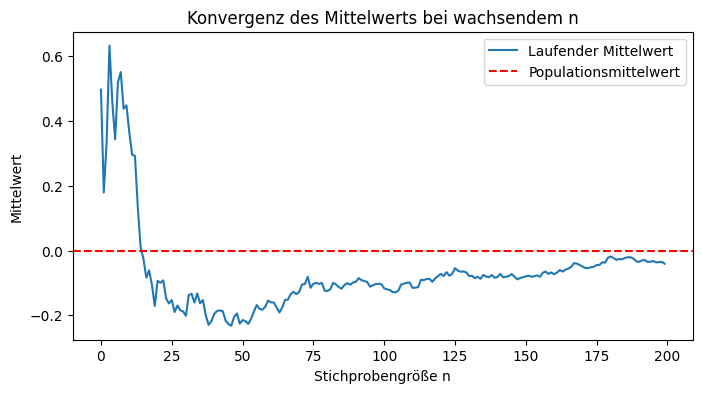

In [135]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
mu = 0
sigma = 1
max_n = 200

data = np.random.normal(mu, sigma, max_n)
cumsum = np.cumsum(data)
running_mean = cumsum / np.arange(1, max_n + 1)

plt.figure(figsize=(8,4))
plt.plot(running_mean, label="Laufender Mittelwert")
plt.axhline(mu, color="red", linestyle="--", label="Populationsmittelwert")
plt.xlabel("Stichprobengröße n")
plt.ylabel("Mittelwert")
plt.title("Konvergenz des Mittelwerts bei wachsendem n")
plt.legend()
plt.show()

### 6.3 Beispiele in Data Science

Train/Validation Split: Kleine Trainingsmengen führen zu unstabilen Modellmetriken.

Bootstrapping / Resampling: Wiederholtes Ziehen kleiner Stichproben zeigt, wie sich der Mittelwert verteilt.

Feature-Statistiken: Mittelwert und Varianz stabilisieren sich erst bei ausreichend großen $n$.

## Bootstrapping als Beispiel

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider, Checkbox

np.random.seed(42)

# Population
population_data = np.random.normal(loc=50, scale=10, size=100)
true_mean = np.mean(population_data)
true_median = np.median(population_data)

def bootstrap_with_mean_tracking(sample_size=20, n_bootstrap=500, add_outlier=False):
    # Stichprobe ziehen
    sample = np.random.choice(population_data, size=sample_size, replace=True)
    
    if add_outlier:
        sample[-1] += 50  # Extremer Ausreißer
    
    sample_mean = np.mean(sample)
    sample_median = np.median(sample)
    
    # Bootstrapping
    bootstrap_means = [np.mean(np.random.choice(sample, size=sample_size, replace=True))
                       for _ in range(n_bootstrap)]
    bootstrap_medians = [np.median(np.random.choice(sample, size=sample_size, replace=True))
                         for _ in range(n_bootstrap)]
    
    # Konfidenzintervalle
    mean_lower, mean_upper = np.percentile(bootstrap_means, [2.5, 97.5])
    median_lower, median_upper = np.percentile(bootstrap_medians, [2.5, 97.5])
    
    # Mittelwert der Bootstrap-Mittelwerte
    mean_of_means = np.mean(bootstrap_means)
    
    plt.figure(figsize=(9,5))
    
    # Histogramme
    plt.hist(bootstrap_means, bins=30, density=True, alpha=0.5, color="skyblue", label="Bootstrap Mittelwerte")
    plt.hist(bootstrap_medians, bins=30, density=True, alpha=0.5, color="salmon", label="Bootstrap Mediane")
    
    # Stichprobe Linien
    plt.axvline(sample_mean, color="blue", linestyle="--", linewidth=2, label="Stichproben-Mittelwert")
    plt.axvline(sample_median, color="red", linestyle="--", linewidth=2, label="Stichproben-Median")
    
    # Populationswerte
    plt.axvline(true_mean, color="navy", linestyle=":", linewidth=2, label="Populationsmittelwert")
    plt.axvline(true_median, color="darkred", linestyle=":", linewidth=2, label="Populationsmedian")
    
    # Bootstrap CI
    plt.axvline(mean_lower, color="blue", linestyle=":", linewidth=2, label="95%-CI Mittelwert")
    plt.axvline(mean_upper, color="blue", linestyle=":", linewidth=2)
    plt.axvline(median_lower, color="red", linestyle=":", linewidth=2, label="95%-CI Median")
    plt.axvline(median_upper, color="red", linestyle=":", linewidth=2)
    
    # Mittelwert der Mittelwerte
    plt.axvline(mean_of_means, color="purple", linestyle="-", linewidth=2, label="Mittelwert der Bootstrap-Mittelwerte")
    
    plt.title(f"Bootstrapping Simulation (n={sample_size}, Bootstrap={n_bootstrap})\nAusreißer: {add_outlier}")
    plt.xlabel("Wert")
    plt.ylabel("Dichte")
    plt.legend()
    plt.show()
    
    print(f"Mittelwert der Bootstrap-Mittelwerte: {mean_of_means:.2f}")
    print(f"Stichprobenmittelwert: {sample_mean:.2f}")
    print(f"Wahrer Populationsmittelwert: {true_mean:.2f}")

# Interaktives Widget
interact(
    bootstrap_with_mean_tracking,
    sample_size=IntSlider(min=5, max=80, step=5, value=20, description="Stichprobengröße"),
    n_bootstrap=IntSlider(min=1, max=1000, step=1, value=1, description="Bootstrap-Samples"),
    add_outlier=Checkbox(value=False, description="Ausreißer hinzufügen")
);


interactive(children=(IntSlider(value=20, description='Stichprobengröße', max=80, min=5, step=5), IntSlider(va…

: 

### Bootstrapping – Interaktives Widget

---

Dieses Widget demonstriert **Bootstrapping** anhand einer Stichprobe aus einer Population und zeigt gleichzeitig die Wirkung von **Ausreißern**, den Unterschied zwischen **Mittelwert und Median** und die Konvergenz des **Mittelwerts der Mittelwerte**.

---

#### 1. Grundidee von Bootstrapping

1. Ziehe eine **Stichprobe** aus der Population.  
2. Erstelle viele **Bootstrap-Stichproben** durch Ziehen mit Zurücklegen aus dieser Stichprobe.  
3. Berechne für jede Bootstraps-Stichprobe die **Statistik** deiner Wahl (z.B. Mittelwert oder Median).  
4. Analysiere die Verteilung dieser Bootstraps, z.B. zur Schätzung von **Konfidenzintervallen** oder zur Untersuchung der **Unsicherheit des Schätzers**.

> Wichtig: Bootstrapping arbeitet nur mit der **vorhandenen Stichprobe**, nicht der gesamten Population.

---

#### 2. Visualisierung im Widget

- **Histogramme:** Zeigen die Verteilung der Bootstrap-Mittelwerte (blau) und Bootstrap-Mediane (rot).  
- **Stichprobenlinien:**  
  - Orange gestrichelt: Mittelwert der gezogenen Stichprobe  
  - Rot gestrichelt: Median der gezogenen Stichprobe  
- **Populationslinien:**  
  - Dunkelblau gestrichelt: Wahrer Mittelwert  
  - Dunkelrot gestrichelt: Wahrer Median  
- **Konfidenzintervalle:**  
  - Blaue Punkte: 95%-CI für den Mittelwert  
  - Rote Punkte: 95%-CI für den Median  
- **Mittelwert der Bootstrap-Mittelwerte:**  
  - Lila Linie: zeigt, wie sich der Mittelwert der Bootstrap-Mittelwerte dem wahren Populationsmittelwert annähert.

---

#### 3. Interaktive Steuerung

- **Stichprobengröße (`sample_size`)**:  
  Größere Stichproben erzeugen stabilere Bootstrap-Mittelwerte, schmalere Histogramme und engere Konfidenzintervalle.  

- **Anzahl Bootstrap-Samples (`n_bootstrap`)**:  
  Mehr Wiederholungen glätten die Histogramme und stabilisieren die Konfidenzintervalle.  

- **Ausreißer hinzufügen (`add_outlier`)**:  
  Demonstriert die Empfindlichkeit des Mittelwerts gegenüber extremen Werten.  
  - Mittelwert verschiebt sich stark und CI wird breiter  
  - Median bleibt stabil und robust  

---

#### 4. Beobachtbare Effekte

1. **Konvergenz des Mittelwerts der Mittelwerte:**  
   - Der Mittelwert der Bootstrap-Mittelwerte nähert sich dem Mittelwert der Stichprobe, der ein Schätzer für den wahren Mittelwert ist.  

2. **Robustheit des Medians:**  
   - Auch wenn ein Ausreißer vorhanden ist, bleibt der Median fast unverändert.  

3. **Unsicherheit der Schätzung:**  
   - Die Breite der Bootstrap-Verteilung visualisiert die Schwankungsbreite des Mittelwerts oder Medians bei wiederholtem Ziehen von Stichproben.  

---

#### 5. Lernziele mit dem Widget

- Verstehen, wie Bootstrapping funktioniert und warum es nützlich ist  
- Beobachten, wie Stichprobengröße die Stabilität der Schätzung beeinflusst  
- Den Effekt von Ausreißern auf Mittelwert und Median erkennen  
- Die Beziehung zwischen Stichprobenmittelwert, Mittelwert der Bootstrap-Mittelwerte und dem wahren Mittelwert der Population nachvollziehen  

> Tipp: Spiele interaktiv mit allen Reglern und beobachte die Veränderungen in Echtzeit, um ein intuitives Verständnis für Bootstrapping zu entwickeln.
